# Titanic EDA — First Exploratory Data Analysis
**Track:** Neurofive ML Track — Task 1: Data Science Toolkit Setup

Goal: load the Titanic dataset, inspect its shape and quality, and write a short data story before any modeling happens.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

## 2. Load the dataset
Dataset: **Titanic - Machine Learning from Disaster** (Kaggle). Place `titanic.csv` in the same folder as this notebook, or update the path below.

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. First look: shape, types, summary stats

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.describe(include='object')

/tmp/ipykernel_549/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## 4. Missing values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0').sort_values('missing_count', ascending=False)

,missing_count,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


## 5. Categorical vs. numerical columns

In [7]:
numerical = df.select_dtypes(include=[np.number]).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()
print('Numerical columns:', numerical)
print('Categorical columns:', categorical)

Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


/tmp/ipykernel_549/287050167.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object']).columns.tolist()


## 6. Data Story — What I Found

- The dataset has **891 rows and 12 columns**, one row per passenger.
- Three columns have missing values: **Age** (177 missing, ~20%), **Cabin** (687 missing, ~77% — mostly unusable as-is), and **Embarked** (2 missing, negligible).
- **Numerical** columns: `PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`. Note `Survived` and `Pclass` are really categorical/ordinal encoded as numbers.
- **Categorical** columns: `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`.
- Fare and Age are right-skewed (a few very high fares/older passengers pull the mean above the median) — worth log-transforming or capping before modeling.
- Before any ML: I'll need a strategy for Age (impute), Cabin (drop or extract deck letter), and Embarked (impute with mode) — decisions for the next task, not this one.

---
# Task 2 — Clean & Visualize Real-World Data
Building on the EDA above: handle missing values, detect outliers, visualize, and reason about what drives survival.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 7. Handling missing values

**Decisions:**
- **Age** (177 missing, ~20%): fill with the **median** (28.0) rather than the mean, since Age is right-skewed and the median is more robust to the older outliers pulling the mean up (29.7).
- **Embarked** (2 missing): fill with the **mode** ('S' — Southampton), since only 2 rows are affected and mode is the safest default for a categorical column with a dominant class.
- **Cabin** (687 missing, ~77%): too sparse to impute meaningfully. Instead of filling, I create a new binary flag `HasCabin` (1 if cabin is known, 0 if not) — the *presence* of a cabin record turns out to correlate with class/fare, so it's more useful as a feature than trying to guess the actual cabin.

In [9]:
df_clean = df.copy()

# Age -> median imputation (robust to skew)
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Embarked -> mode imputation (only 2 missing)
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Cabin -> convert to a binary 'HasCabin' flag instead of imputing
df_clean['HasCabin'] = df_clean['Cabin'].notna().astype(int)
df_clean = df_clean.drop(columns=['Cabin'])

print('Missing values after cleaning:')
df_clean.isnull().sum()

Missing values after cleaning:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64

## 8. Outlier detection — boxplot on Fare

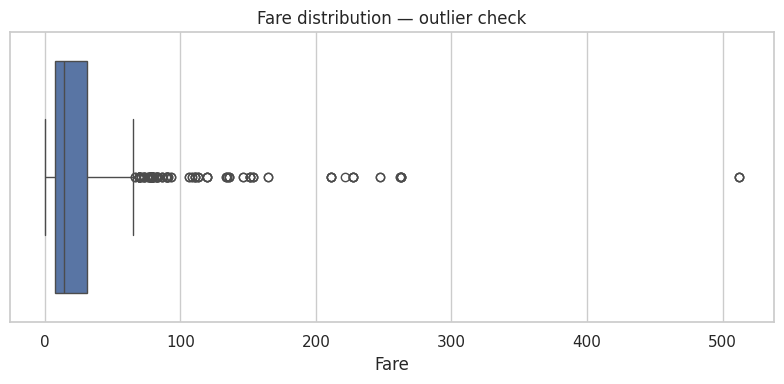

IQR upper bound: 65.63 | Fares above it (outliers): 116


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df_clean['Fare'], ax=ax, color='#4C72B0')
ax.set_title('Fare distribution — outlier check')
plt.tight_layout()
plt.show()

q1, q3 = df_clean['Fare'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
n_outliers = (df_clean['Fare'] > upper_bound).sum()
print(f'IQR upper bound: {upper_bound:.2f} | Fares above it (outliers): {n_outliers}')

**Observation:** Fare has a long right tail — most tickets cost under ~£30, but a handful (mostly 1st class) cost well over £200, including the max of £512. These are legitimate high-fare 1st-class tickets, not data errors, so I'm keeping them rather than dropping them — they carry real signal about class and survival.

## 9. Visualizations

### 9.1 Histogram — Age distribution

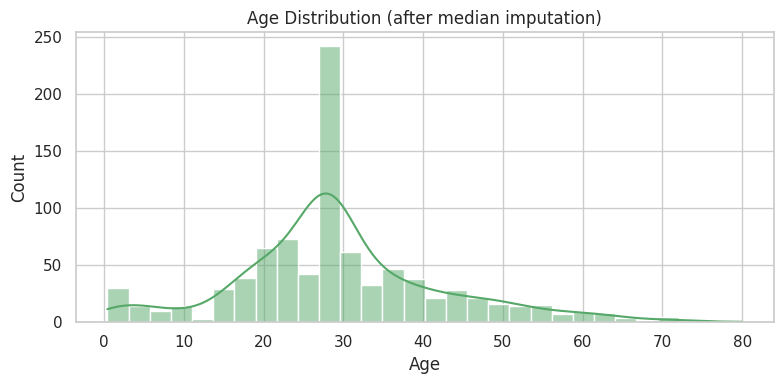

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_clean['Age'], bins=30, kde=True, color='#55A868', ax=ax)
ax.set_title('Age Distribution (after median imputation)')
ax.set_xlabel('Age')
plt.tight_layout()
plt.show()

### 9.2 Boxplot — Fare by Passenger Class

/tmp/ipykernel_549/4005851814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df_clean, ax=ax, palette='muted')


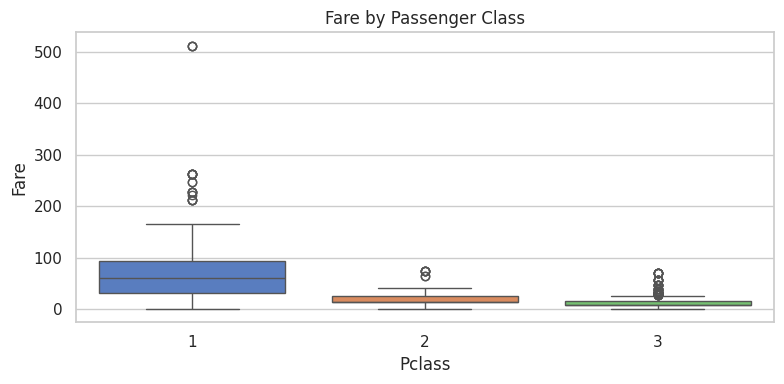

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x='Pclass', y='Fare', data=df_clean, ax=ax, palette='muted')
ax.set_title('Fare by Passenger Class')
plt.tight_layout()
plt.show()

### 9.3 Bar chart — Survival rate by Sex

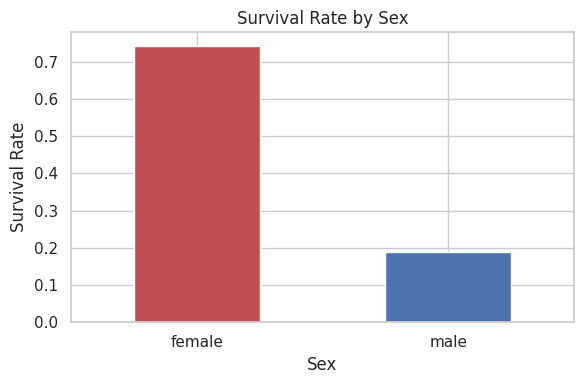

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
survival_by_sex = df_clean.groupby('Sex')['Survived'].mean()
survival_by_sex.plot(kind='bar', color=['#C44E52', '#4C72B0'], ax=ax)
ax.set_title('Survival Rate by Sex')
ax.set_ylabel('Survival Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 9.4 Correlation heatmap

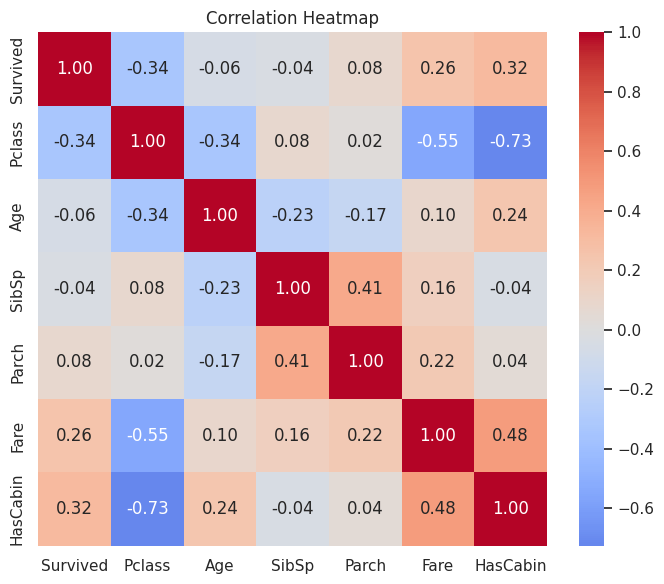

In [14]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin']
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 10. Which feature most affects survival, and why?

**Sex** is the strongest single predictor of survival in this dataset. The bar chart shows women survived at a much higher rate than men (roughly 74% vs 19%), a far bigger gap than any other feature produces on its own. This lines up with the historical "women and children first" evacuation policy on the Titanic.

**Pclass** and **Fare** are the next strongest signals — the correlation heatmap shows `Fare` positively correlated with survival and `Pclass` negatively correlated (recall Pclass 1 = highest class, 3 = lowest), meaning wealthier, higher-class passengers had better odds, likely due to cabin location and lifeboat access. `HasCabin` correlates with survival too, but that's mostly because having a recorded cabin is itself a proxy for being in 1st/2nd class — it's not adding fully independent signal beyond Pclass and Fare.

**Age** and family-size features (`SibSp`, `Parch`) show weaker correlations on their own, though very young children do show a survival bump consistent with the evacuation policy — that's more visible when Age is binned than in the raw correlation number.